In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Set random seed
np.random.seed(42)

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [4]:
train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [5]:
test.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING


In [6]:
print("Training Shape :", train.shape)
print("Testing Shape  :", test.shape)

Training Shape : (7352, 563)
Testing Shape  : (2947, 563)


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


In [8]:
print(train.isnull().sum().sum())
print(test.isnull().sum().sum())

0
0


In [9]:
print("Duplicate rows in train:",
      train.duplicated().sum())

print("Duplicate rows in test:",
      test.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [10]:
train["Activity"].value_counts()

,count
Activity,
LAYING,1407
STANDING,1374
SITTING,1286
WALKING,1226
WALKING_UPSTAIRS,1073
WALKING_DOWNSTAIRS,986


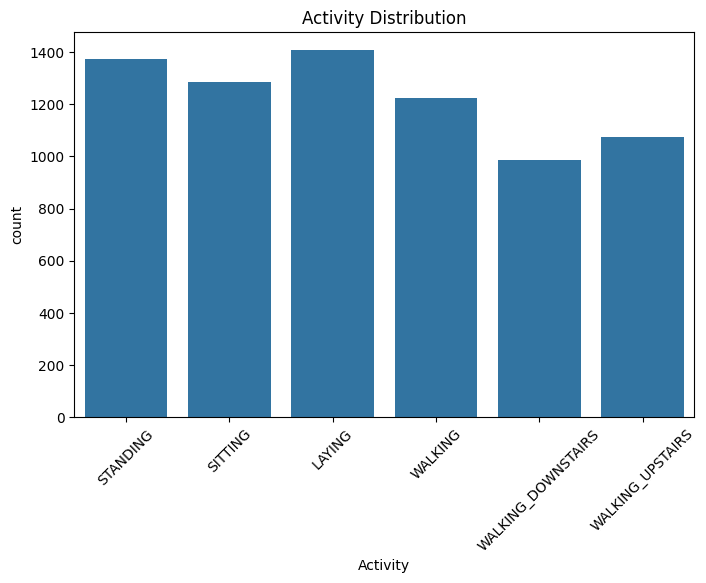

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train,
    x="Activity"
)

plt.xticks(rotation=45)
plt.title("Activity Distribution")

plt.show()

In [12]:
X_train = train.drop("Activity", axis=1)
y_train = train["Activity"]

X_test = test.drop("Activity", axis=1)
y_test = test["Activity"]

In [13]:
print(X_train.shape)
print(X_test.shape)

(7352, 562)
(2947, 562)


In [14]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [15]:
print(encoder.classes_)

['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
X_train_final, X_valid, y_train_final, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [18]:
print("Training   :", X_train_final.shape)
print("Validation :", X_valid.shape)
print("Testing    :", X_test.shape)

Training   : (5881, 562)
Validation : (1471, 562)
Testing    : (2947, 562)


In [19]:
print(pd.Series(y_train_final).value_counts())
print(pd.Series(y_valid).value_counts())

0    1125
2    1099
1    1029
3     981
5     858
4     789
Name: count, dtype: int64
0    282
2    275
1    257
3    245
5    215
4    197
Name: count, dtype: int64


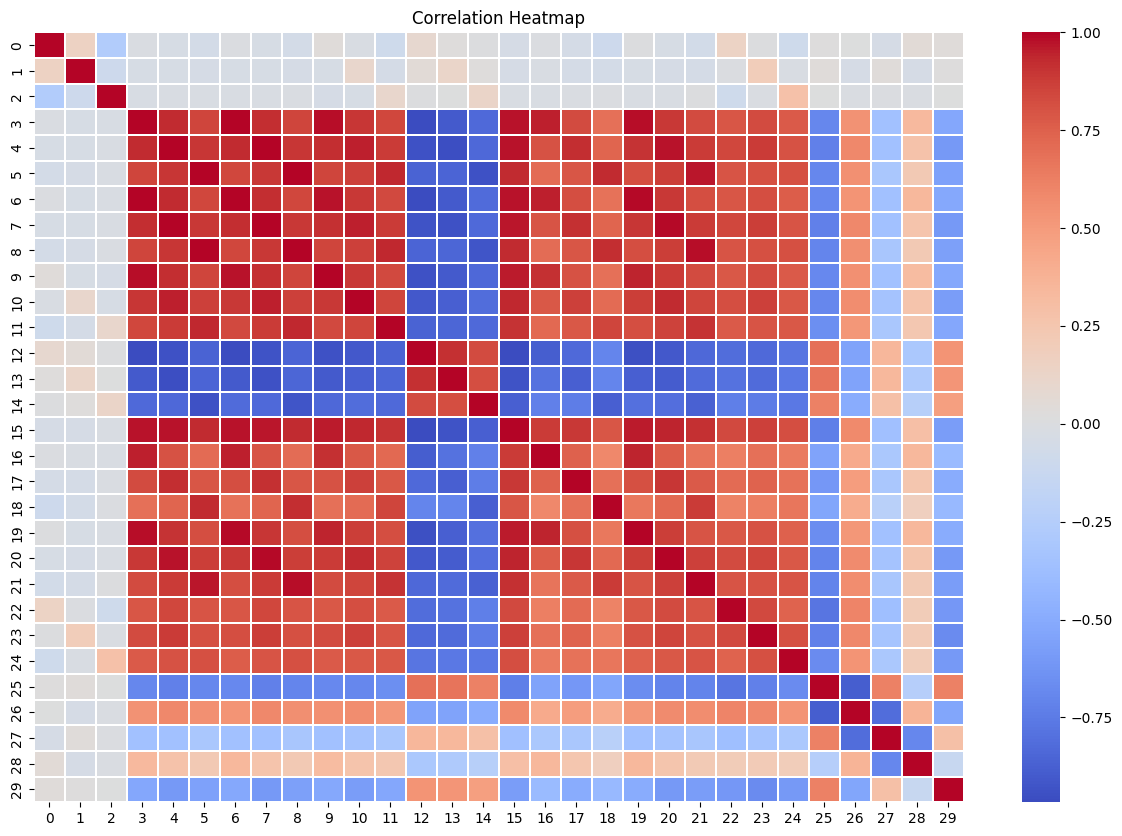

In [20]:
corr = pd.DataFrame(
    X_train_final
).iloc[:, :30].corr()

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.2
)

plt.title("Correlation Heatmap")

plt.show()

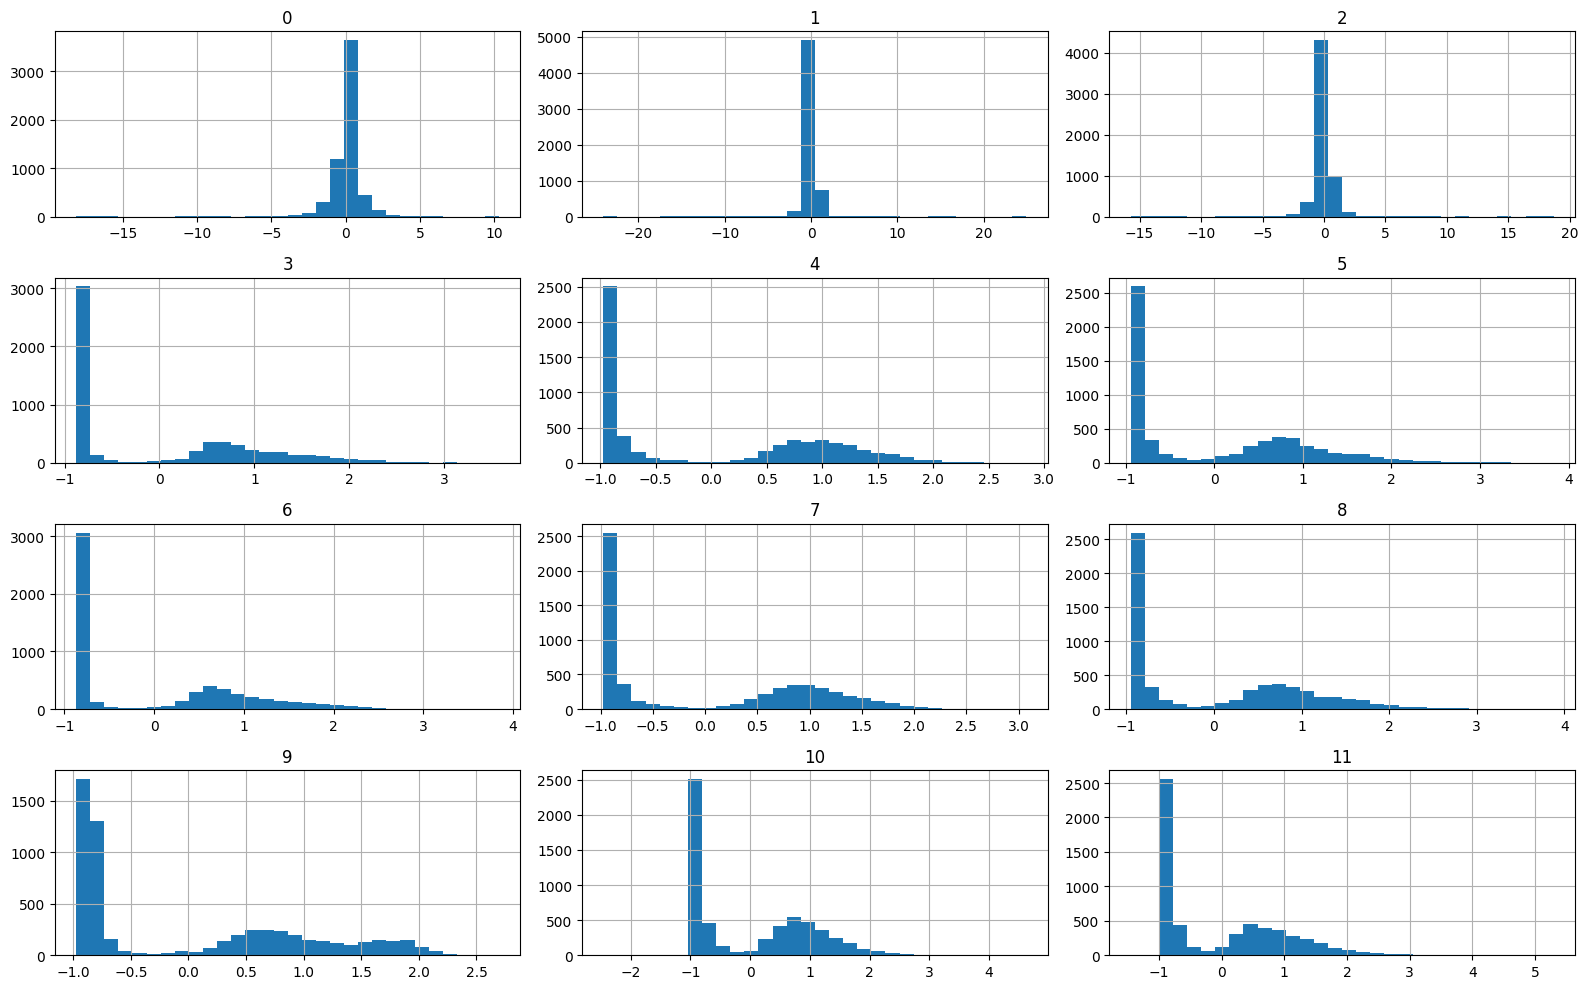

In [21]:
feature_df = pd.DataFrame(X_train_final)

feature_df.iloc[:, :12].hist(
    figsize=(16,10),
    bins=30
)

plt.tight_layout()
plt.show()

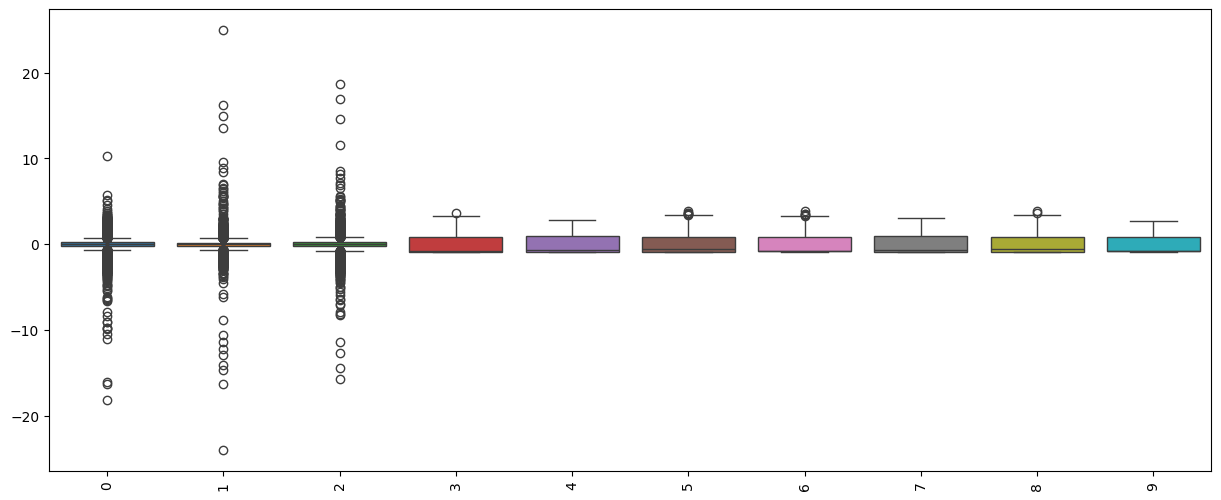

In [22]:
plt.figure(figsize=(15,6))

sns.boxplot(
    data=feature_df.iloc[:, :10]
)

plt.xticks(rotation=90)

plt.show()

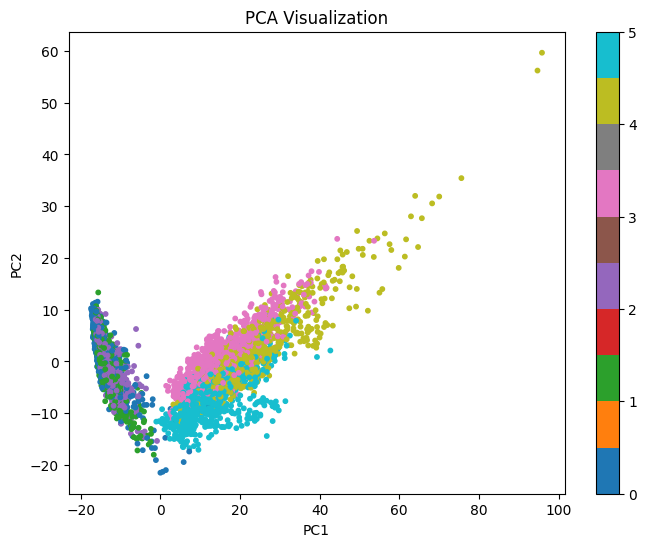

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_final)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_train_final,
    cmap="tab10",
    s=10
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")

plt.colorbar(scatter)

plt.show()

In [24]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Dictionary to store model accuracies
results = {}

In [26]:
lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr.fit(X_train_final, y_train_final)

LogisticRegression(max_iter=2000, random_state=42)

In [27]:
lr_pred = lr.predict(X_valid)

lr_acc = accuracy_score(y_valid, lr_pred)

results["Logistic Regression"] = lr_acc

print("Validation Accuracy:", lr_acc)

Validation Accuracy: 0.9850441876274643


In [28]:
print(
    classification_report(
        y_valid,
        lr_pred,
        target_names=encoder.classes_
    )
)

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       282
           SITTING       0.96      0.96      0.96       257
          STANDING       0.96      0.96      0.96       275
           WALKING       1.00      1.00      1.00       245
WALKING_DOWNSTAIRS       1.00      1.00      1.00       197
  WALKING_UPSTAIRS       1.00      1.00      1.00       215

          accuracy                           0.99      1471
         macro avg       0.99      0.99      0.99      1471
      weighted avg       0.99      0.99      0.99      1471



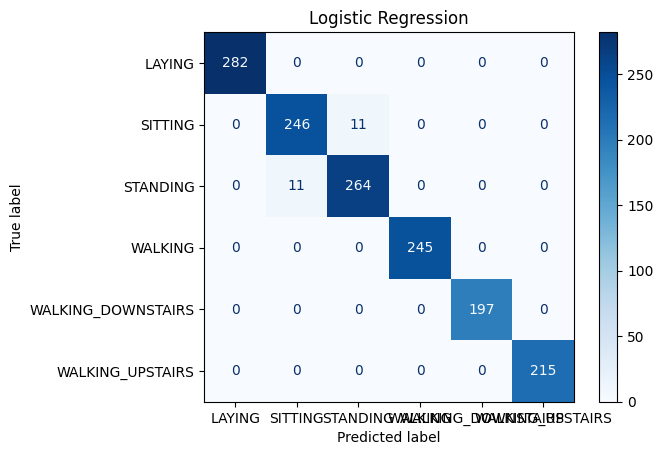

In [29]:
cm = confusion_matrix(y_valid, lr_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
).plot(cmap="Blues")

plt.title("Logistic Regression")
plt.show()

In [30]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="minkowski"
)

knn.fit(X_train_final, y_train_final)

KNeighborsClassifier(weights='distance')

In [31]:
knn_pred = knn.predict(X_valid)

knn_acc = accuracy_score(y_valid, knn_pred)

results["KNN"] = knn_acc

print("Validation Accuracy:", knn_acc)

Validation Accuracy: 0.9639700883752549


In [32]:
print(
    classification_report(
        y_valid,
        knn_pred,
        target_names=encoder.classes_
    )
)

                    precision    recall  f1-score   support

            LAYING       1.00      0.99      0.99       282
           SITTING       0.95      0.86      0.90       257
          STANDING       0.88      0.97      0.92       275
           WALKING       0.98      1.00      0.99       245
WALKING_DOWNSTAIRS       1.00      0.98      0.99       197
  WALKING_UPSTAIRS       1.00      0.99      0.99       215

          accuracy                           0.96      1471
         macro avg       0.97      0.97      0.97      1471
      weighted avg       0.97      0.96      0.96      1471



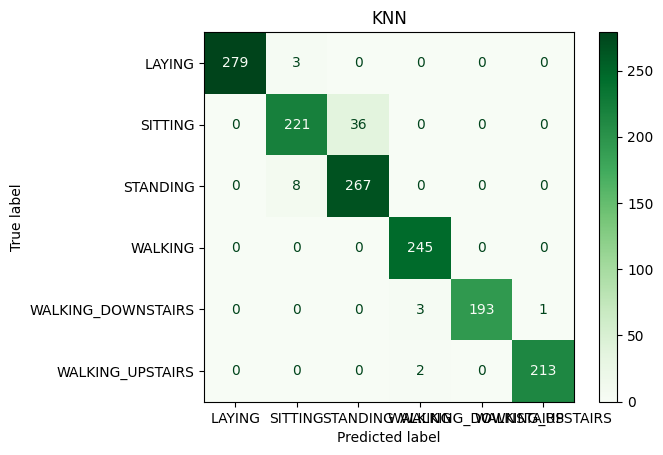

In [33]:
cm = confusion_matrix(y_valid, knn_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
).plot(cmap="Greens")

plt.title("KNN")
plt.show()

In [34]:
dt = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=4,
    random_state=42
)

dt.fit(X_train_final, y_train_final)

DecisionTreeClassifier(max_depth=20, min_samples_split=4, random_state=42)

In [35]:
dt_pred = dt.predict(X_valid)

dt_acc = accuracy_score(y_valid, dt_pred)

results["Decision Tree"] = dt_acc

print("Validation Accuracy:", dt_acc)

Validation Accuracy: 0.9374575118966689


In [36]:
print(
    classification_report(
        y_valid,
        dt_pred,
        target_names=encoder.classes_
    )
)

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       282
           SITTING       0.90      0.90      0.90       257
          STANDING       0.91      0.91      0.91       275
           WALKING       0.94      0.96      0.95       245
WALKING_DOWNSTAIRS       0.92      0.95      0.94       197
  WALKING_UPSTAIRS       0.96      0.90      0.93       215

          accuracy                           0.94      1471
         macro avg       0.94      0.94      0.94      1471
      weighted avg       0.94      0.94      0.94      1471



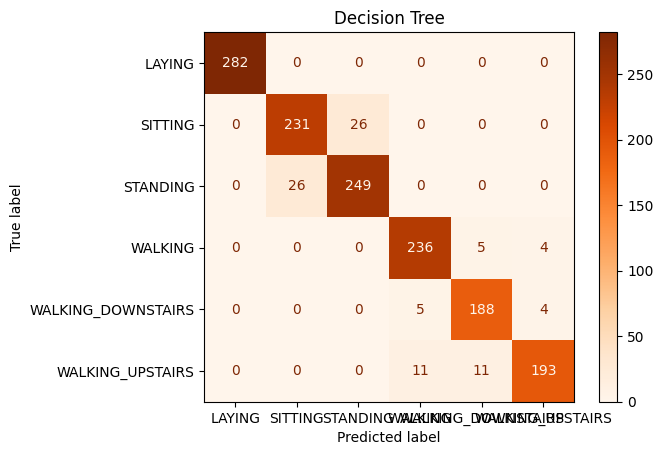

In [37]:
cm = confusion_matrix(y_valid, dt_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
).plot(cmap="Oranges")

plt.title("Decision Tree")
plt.show()

In [38]:
comparison = pd.DataFrame({
    "Model": results.keys(),
    "Validation Accuracy": results.values()
})

comparison = comparison.sort_values(
    by="Validation Accuracy",
    ascending=False
)

comparison

,Model,Validation Accuracy
0,Logistic Regression,0.985044
1,KNN,0.963970
2,Decision Tree,0.937458


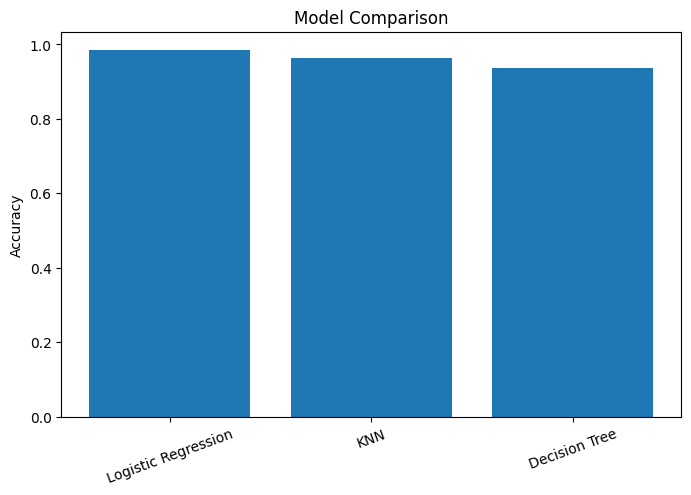

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Validation Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=20)

plt.show()

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [41]:
!pip install -q xgboost

In [42]:
from xgboost import XGBClassifier

In [43]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train_final)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [44]:
rf_pred = rf.predict(X_valid)

rf_acc = accuracy_score(y_valid, rf_pred)

results["Random Forest"] = rf_acc

print("Validation Accuracy:", rf_acc)

Validation Accuracy: 0.9884432358939497


In [45]:
print(classification_report(
    y_valid,
    rf_pred,
    target_names=encoder.classes_
))

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       282
           SITTING       0.99      0.96      0.97       257
          STANDING       0.96      0.99      0.98       275
           WALKING       1.00      0.99      0.99       245
WALKING_DOWNSTAIRS       0.98      1.00      0.99       197
  WALKING_UPSTAIRS       1.00      1.00      1.00       215

          accuracy                           0.99      1471
         macro avg       0.99      0.99      0.99      1471
      weighted avg       0.99      0.99      0.99      1471



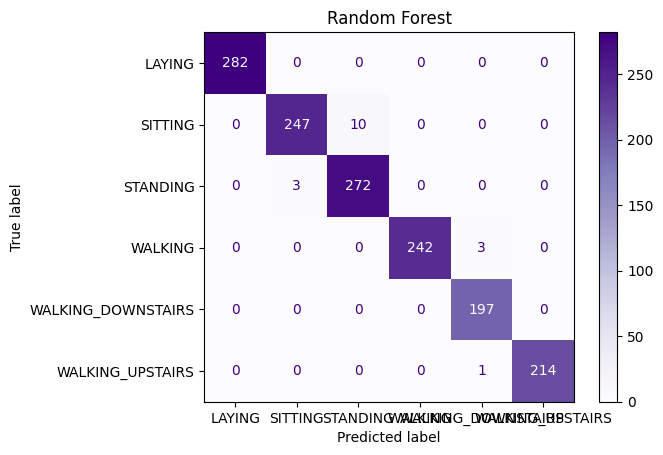

In [46]:
cm = confusion_matrix(y_valid, rf_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
).plot(cmap="Purples")

plt.title("Random Forest")
plt.show()

In [47]:
svm = SVC(
    kernel="rbf",
    C=5,
    gamma="scale",
    random_state=42
)

svm.fit(X_train_final, y_train_final)

SVC(C=5, random_state=42)

In [48]:
svm_pred = svm.predict(X_valid)

svm_acc = accuracy_score(y_valid, svm_pred)

results["SVM"] = svm_acc

print("Validation Accuracy:", svm_acc)

Validation Accuracy: 0.9898028552005439


In [49]:
print(classification_report(
    y_valid,
    svm_pred,
    target_names=encoder.classes_
))

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       282
           SITTING       0.98      0.96      0.97       257
          STANDING       0.97      0.98      0.97       275
           WALKING       1.00      1.00      1.00       245
WALKING_DOWNSTAIRS       1.00      1.00      1.00       197
  WALKING_UPSTAIRS       1.00      1.00      1.00       215

          accuracy                           0.99      1471
         macro avg       0.99      0.99      0.99      1471
      weighted avg       0.99      0.99      0.99      1471



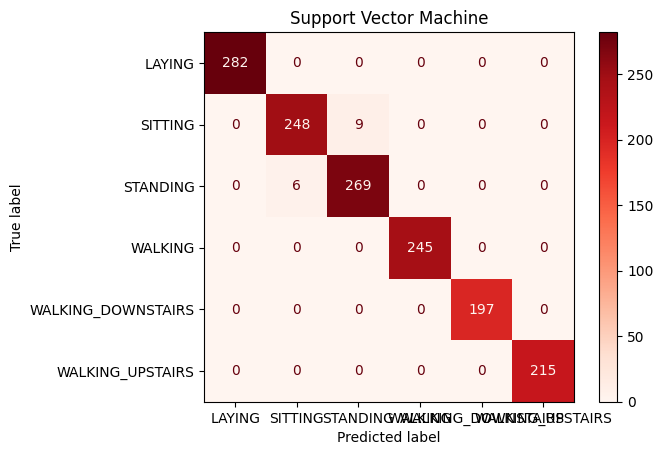

In [50]:
cm = confusion_matrix(y_valid, svm_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
).plot(cmap="Reds")

plt.title("Support Vector Machine")
plt.show()

In [51]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="multi:softprob",
    num_class=len(encoder.classes_),
    eval_metric="mlogloss"
)

xgb.fit(X_train_final, y_train_final)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=6, ...)

In [52]:
xgb_pred = xgb.predict(X_valid)

xgb_acc = accuracy_score(y_valid, xgb_pred)

results["XGBoost"] = xgb_acc

print("Validation Accuracy:", xgb_acc)

Validation Accuracy: 0.9952413324269205


In [53]:
print(classification_report(
    y_valid,
    xgb_pred,
    target_names=encoder.classes_
))

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       282
           SITTING       1.00      0.98      0.99       257
          STANDING       0.99      1.00      0.99       275
           WALKING       1.00      1.00      1.00       245
WALKING_DOWNSTAIRS       1.00      0.99      1.00       197
  WALKING_UPSTAIRS       0.99      1.00      1.00       215

          accuracy                           1.00      1471
         macro avg       1.00      1.00      1.00      1471
      weighted avg       1.00      1.00      1.00      1471



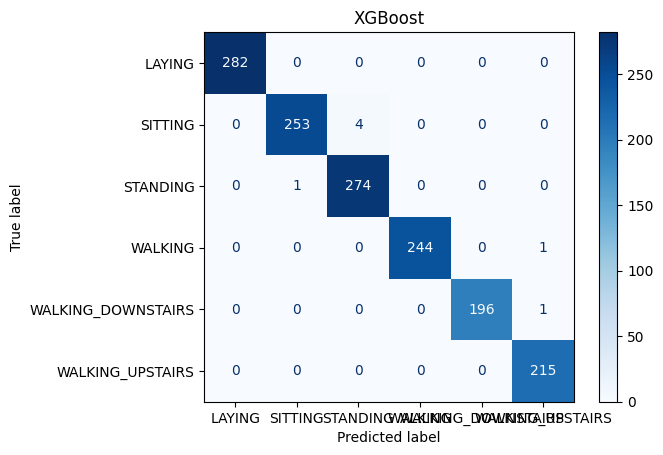

In [54]:
cm = confusion_matrix(y_valid, xgb_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
).plot(cmap="Blues")

plt.title("XGBoost")
plt.show()

In [55]:
comparison = pd.DataFrame({
    "Model": list(results.keys()),
    "Validation Accuracy": list(results.values())
})

comparison = comparison.sort_values(
    by="Validation Accuracy",
    ascending=False
)

comparison

,Model,Validation Accuracy
5,XGBoost,0.995241
4,SVM,0.989803
3,Random Forest,0.988443
0,Logistic Regression,0.985044
1,KNN,0.963970
2,Decision Tree,0.937458


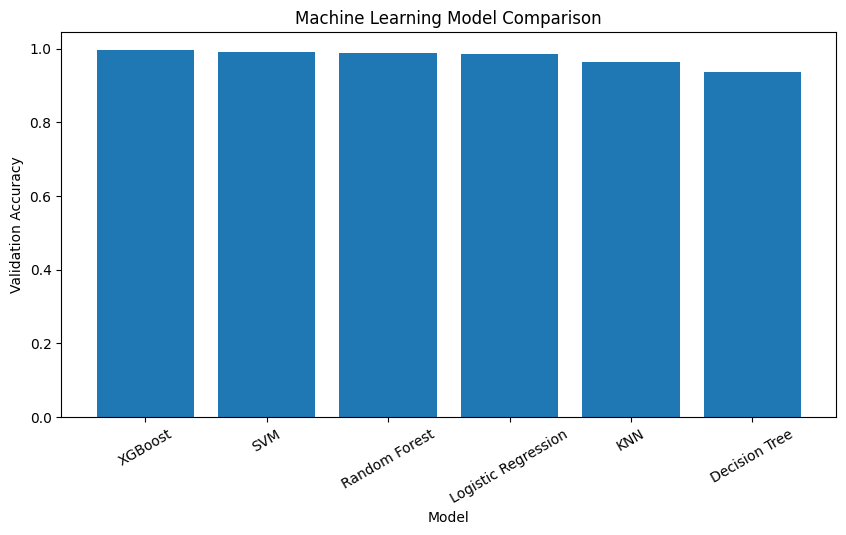

In [56]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison["Model"],
    comparison["Validation Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.title("Machine Learning Model Comparison")

plt.xticks(rotation=30)

plt.show()

In [57]:
best_model_name = comparison.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [58]:
test_pred = xgb.predict(X_test)

print("Test Accuracy:",
      accuracy_score(y_test, test_pred))

Test Accuracy: 0.9358669833729216


In [59]:
print(classification_report(
    y_test,
    test_pred,
    target_names=encoder.classes_
))

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.92      0.85      0.89       491
          STANDING       0.88      0.94      0.90       532
           WALKING       0.93      0.98      0.95       496
WALKING_DOWNSTAIRS       0.97      0.91      0.94       420
  WALKING_UPSTAIRS       0.92      0.92      0.92       471

          accuracy                           0.94      2947
         macro avg       0.94      0.93      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



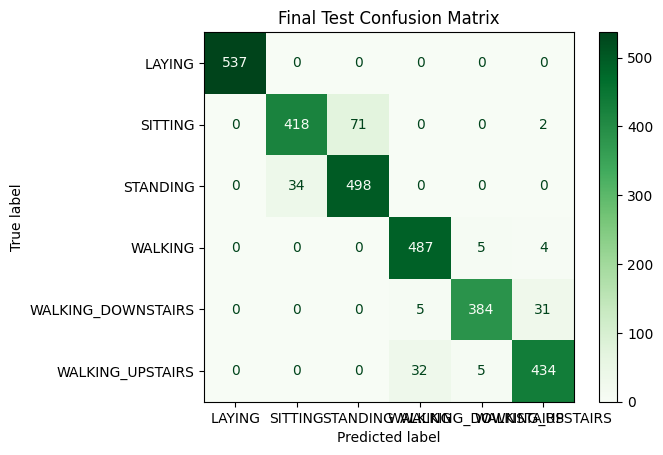

In [60]:
cm = confusion_matrix(y_test, test_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
).plot(cmap="Greens")

plt.title("Final Test Confusion Matrix")

plt.show()

In [61]:
joblib.dump(xgb, "har_xgboost.pkl")

['har_xgboost.pkl']

In [80]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

In [81]:
print(X_train_final.shape)
print(X_valid.shape)
print(X_test.shape)

(5881, 562)
(1471, 562)
(2947, 562)


In [64]:
X_train_lstm = X_train_final.reshape(
    X_train_final.shape[0],
    X_train_final.shape[1],
    1
)

X_valid_lstm = X_valid.reshape(
    X_valid.shape[0],
    X_valid.shape[1],
    1
)

X_test_lstm = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

In [65]:
print(X_train_lstm.shape)

(5881, 562, 1)


In [66]:
model = Sequential()

model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(561, 1)
    )
)

model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(
    LSTM(
        64,
        return_sequences=False
    )
)

model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(len(encoder.classes_), activation="softmax"))

In [67]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [68]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 561, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 561, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 561, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,286 (473.77 KB)

 Trainable params: 120,902 (472.27 KB)

 Non-trainable params: 384 (1.50 KB)

In [69]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)

In [70]:
history = model.fit(
    X_train_lstm,
    y_train_final,
    validation_data=(
        X_valid_lstm,
        y_valid
    ),
    epochs=50,
    batch_size=64,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.5246 - loss: 1.1096 - val_accuracy: 0.3202 - val_loss: 1.5344 - learning_rate: 0.0010
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.6676 - loss: 0.7304 - val_accuracy: 0.3827 - val_loss: 1.4203 - learning_rate: 0.0010
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.7301 - loss: 0.6312 - val_accuracy: 0.5119 - val_loss: 1.3719 - learning_rate: 0.0010
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.7755 - loss: 0.5413 - val_accuracy: 0.5819 - val_loss: 1.1197 - learning_rate: 0.0010
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.7910 - loss: 0.5172 - val_accuracy: 0.6037 - val_loss: 0.8467 - learning_rate: 0.0010
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8048 - loss: 0.4874 - val_accuracy: 0.7811 - val_loss: 0.4931 - learning_rate: 0.0010
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.8118 - loss: 0.4710 - val_ac

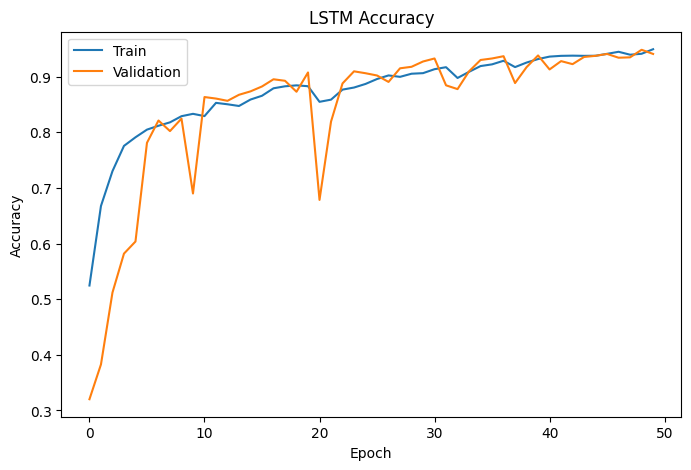

In [71]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Accuracy")

plt.legend()

plt.show()

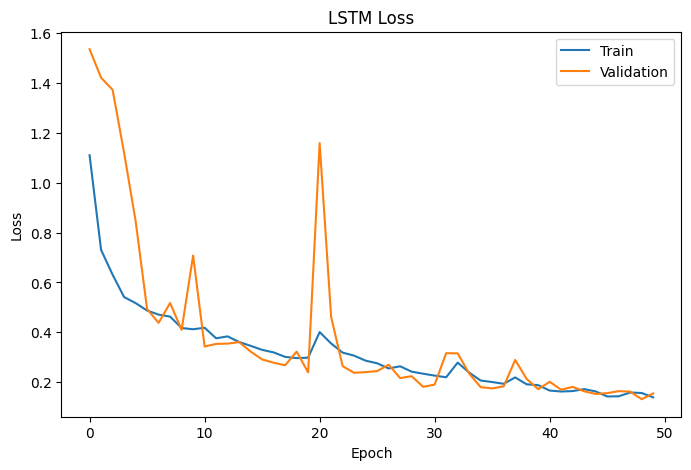

In [72]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss")

plt.legend()

plt.show()

In [73]:
test_loss, test_acc = model.evaluate(
    X_test_lstm,
    y_test,
    verbose=0
)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.8622328042984009


In [74]:
pred_probs = model.predict(X_test_lstm)

predictions = pred_probs.argmax(axis=1)

93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step


In [75]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions,
        target_names=encoder.classes_
    )
)

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.89      0.75      0.82       491
          STANDING       0.80      0.91      0.85       532
           WALKING       0.79      0.87      0.83       496
WALKING_DOWNSTAIRS       0.87      0.81      0.84       420
  WALKING_UPSTAIRS       0.83      0.80      0.81       471

          accuracy                           0.86      2947
         macro avg       0.86      0.86      0.86      2947
      weighted avg       0.87      0.86      0.86      2947



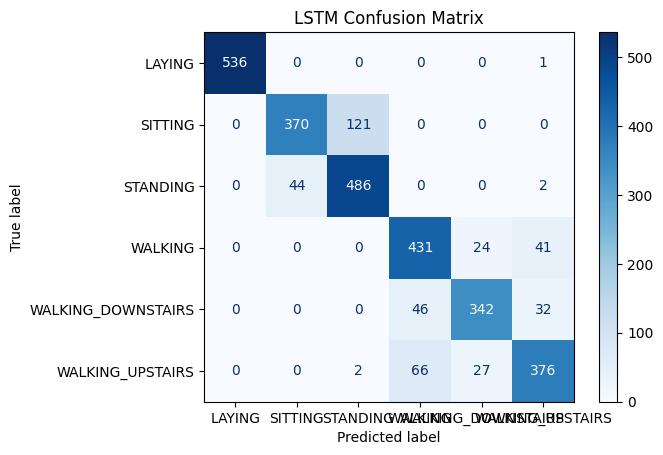

In [76]:
cm = confusion_matrix(
    y_test,
    predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
).plot(cmap="Blues")

plt.title("LSTM Confusion Matrix")

plt.show()

In [82]:
model.save("har_lstm.keras")